**RENDIMIENTO MECSOL**

📊 PREDICCIÓN DE APROBACIÓN - MECÁNICA DE SÓLIDOS
🤖 REGRESIÓN LOGÍSTICA

📂 Cargando datos concatenados...
✅ Datos cargados: 64,295 registros

🔍 Filtrando Mecánica de Sólidos...
✅ Registros de Mecánica de Sólidos: 372
   Estudiantes únicos: 298
   Asignaturas detectadas: ['RESISTENCIA DE MATERIALES', 'MECANICA DE SOLIDOS']

🔄 Preparando datos para el modelo...
   Variables disponibles: ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho']
   Registros originales: 372
   Registros después de limpiar: 372
   Proporción de aprobados: 60.22%

📊 ANÁLISIS EXPLORATORIO

📋 Estadísticas por estado (Aprobado vs Reprobado):

Primer.Par:
          count  mean   std  min  max
Aprobado                             
0           148 27.27 21.82    0   77
1           224 56.29 26.20    0  100

Segundo.Par:
          count  mean   std  min  max
Aprobado                             
0           148 31.05 30.43    0  100
1           224 67.46 27.10    0  100

Tercer.Par:
          c

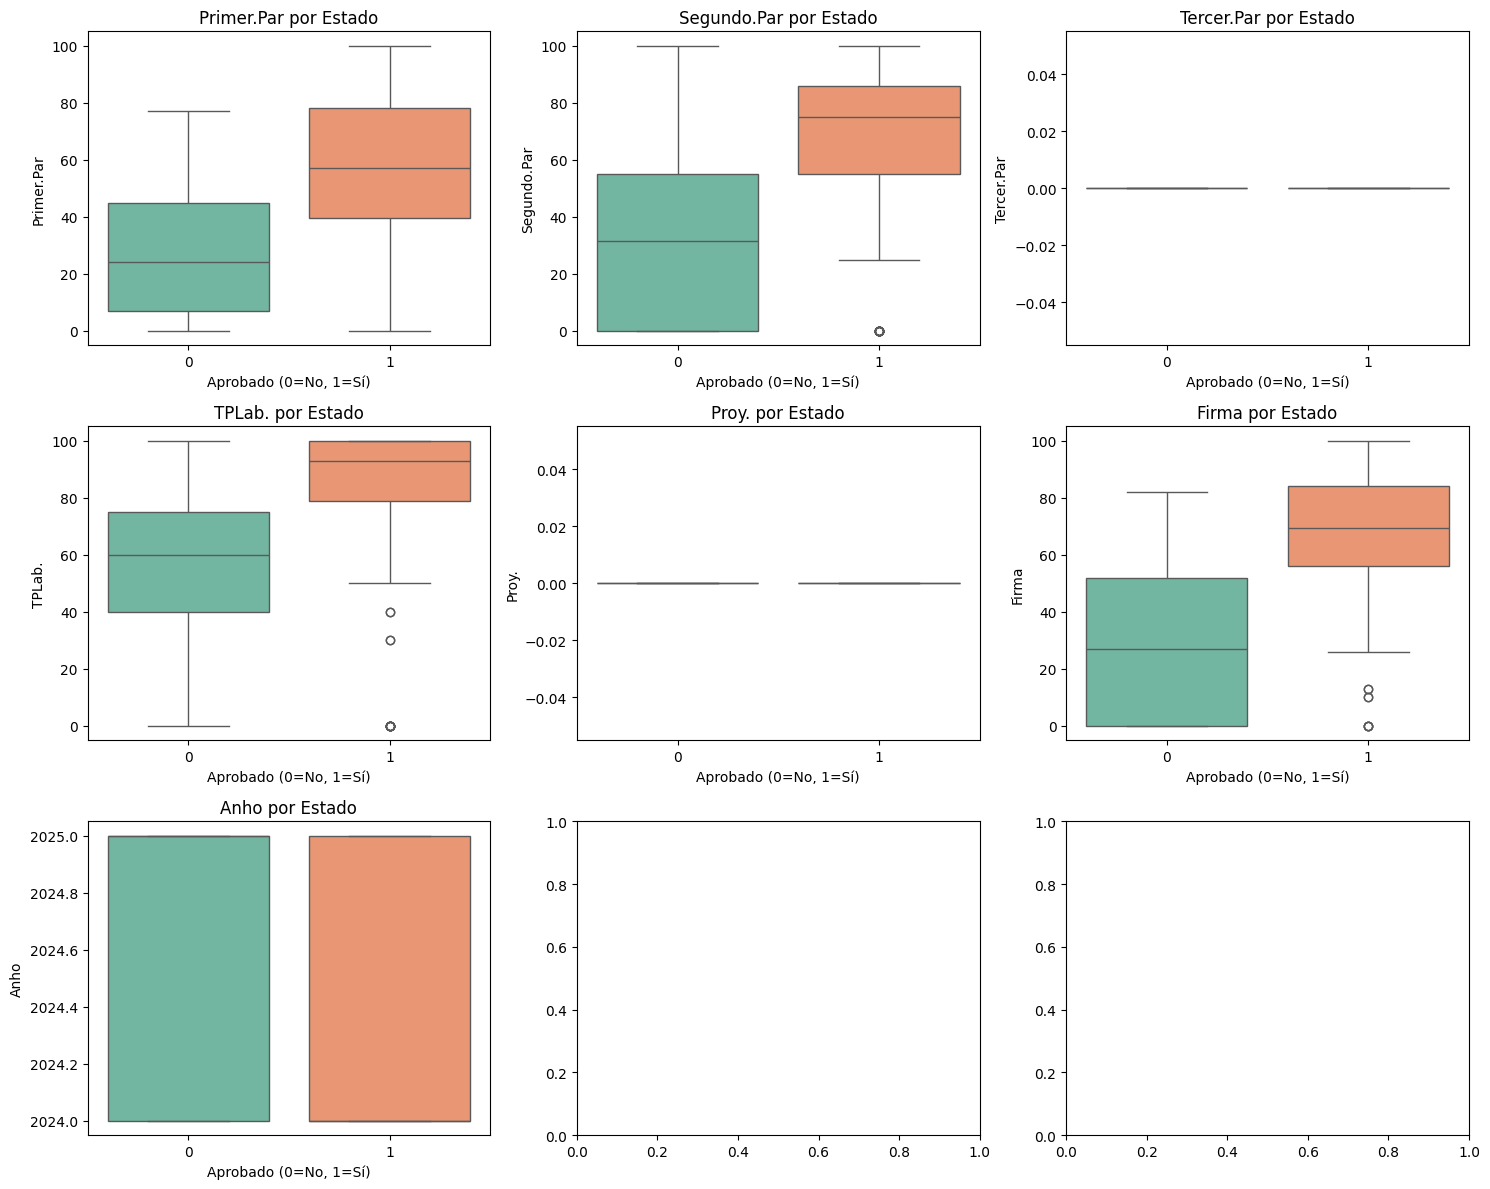

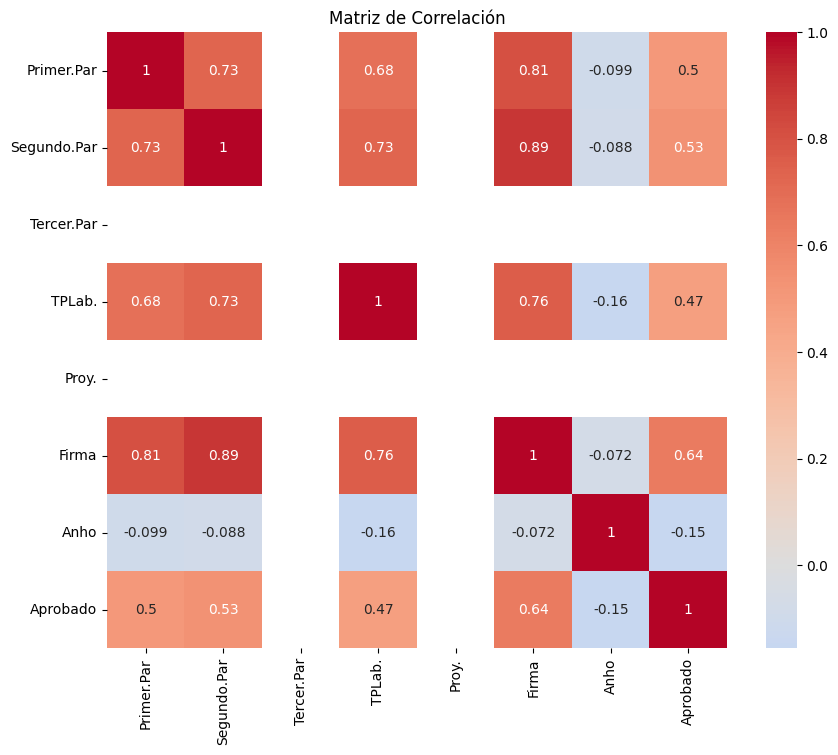


🤖 ENTRENANDO REGRESIÓN LOGÍSTICA

📊 División de datos:
   • Entrenamiento: 260 registros
   • Prueba: 112 registros

📊 MÉTRICAS DEL MODELO:
• Exactitud (Accuracy): 0.821
• AUC-ROC: 0.865

• Reporte de Clasificación:
              precision    recall  f1-score   support

   Reprobado       0.76      0.82      0.79        45
    Aprobado       0.87      0.82      0.85        67

    accuracy                           0.82       112
   macro avg       0.81      0.82      0.82       112
weighted avg       0.83      0.82      0.82       112


• Matriz de Confusión:
           Pred_Reprobado  Pred_Aprobado
Reprobado              37              8
Aprobado               12             55

🎯 Importancia de Variables:
      Variable  Coeficiente  Odds_Ratio
5        Firma         2.00        7.42
0   Primer.Par         0.46        1.58
2   Tercer.Par         0.00        1.00
4        Proy.         0.00        1.00
3       TPLab.        -0.03        0.97
6         Anho        -0.40        0.67


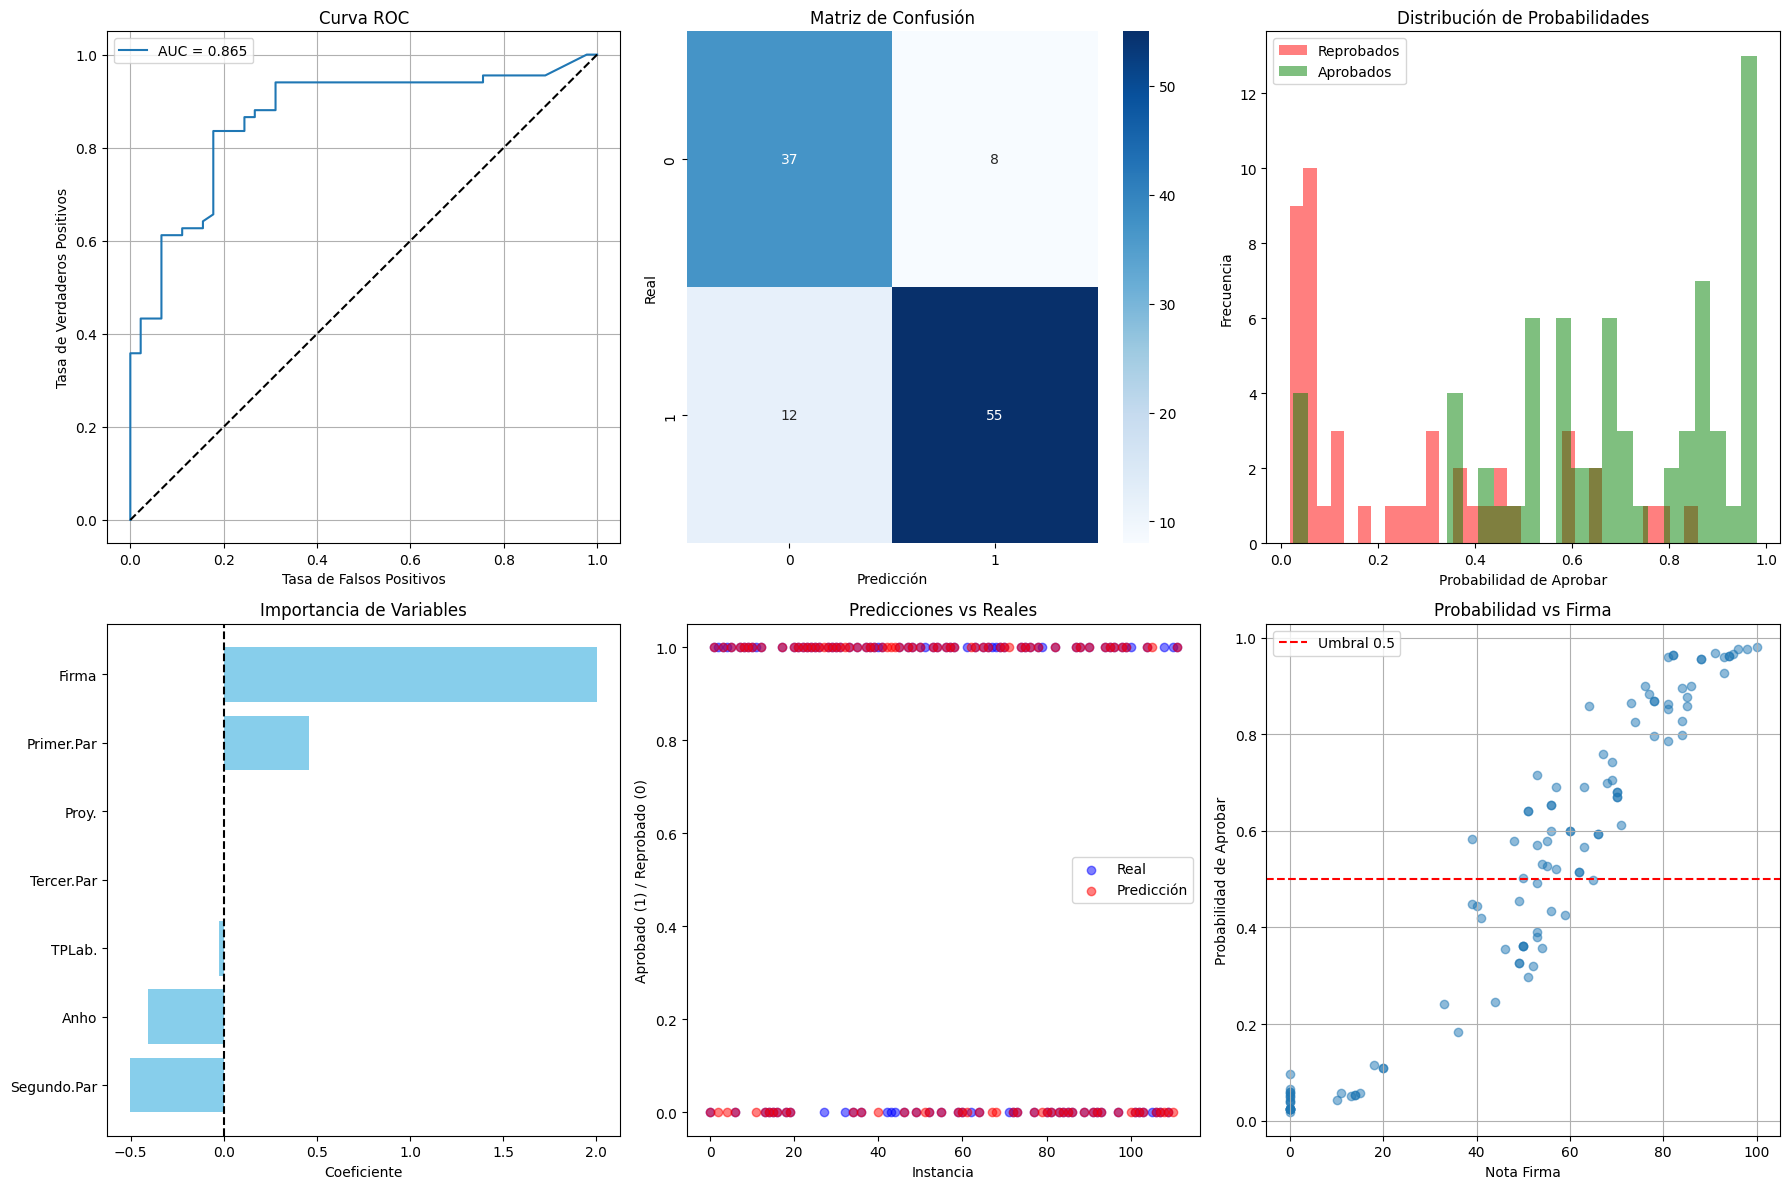


📊 EVALUACIÓN POR AÑO ACADÉMICO
    Año  Registros  Exactitud  Proporción_Aprobados
0  2024        186       0.90                  0.68
1  2025        186       0.80                  0.53


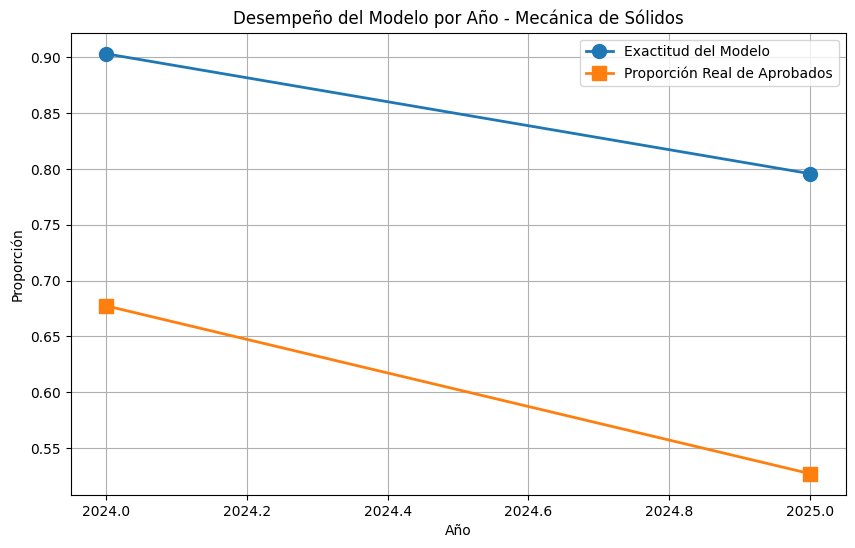


✅ PROCESO COMPLETADO EXITOSAMENTE


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("="*80)
print("📊 PREDICCIÓN DE APROBACIÓN - MECÁNICA DE SÓLIDOS")
print("🤖 REGRESIÓN LOGÍSTICA")
print("="*80)

# =============================================================================
# 1. CARGAR DATOS
# =============================================================================
print("\n📂 Cargando datos concatenados...")
try:
    df = pd.read_csv("/content/datos_concatenados.csv")
    print(f"✅ Datos cargados: {len(df):,} registros")
except FileNotFoundError:
    print("❌ No se encontró el archivo '/content/datos_concatenados.csv'")
    exit()

# =============================================================================
# 2. FILTRAR MECÁNICA DE SÓLIDOS
# =============================================================================
print("\n🔍 Filtrando Mecánica de Sólidos...")

# Búsqueda flexible que contempla variaciones con/sin tildes y nombres afines
patron_solidos = r'MECANICA DE SOLIDOS|MECÁNICA DE SÓLIDOS|SOLIDOS|SÓLIDOS|RESISTENCIA DE MATERIALES'
mask = df['Asignatura'].astype(str).str.upper().str.contains(patron_solidos, na=False, regex=True)

df_solidos = df[mask].copy()
print(f"✅ Registros de Mecánica de Sólidos: {len(df_solidos):,}")

if len(df_solidos) > 0:
    print(f"   Estudiantes únicos: {df_solidos['ALUMNO_ID'].nunique():,}" if 'ALUMNO_ID' in df_solidos.columns else "   (Columna 'ALUMNO_ID' no presente)")
    print(f"   Asignaturas detectadas: {df_solidos['Asignatura'].unique().tolist()}")
else:
    print("❌ No se encontraron registros para Mecánica de Sólidos. Revisa los nombres de las materias en df['Asignatura'].unique().")
    exit()

# =============================================================================
# 3. PREPARAR DATOS
# =============================================================================
print("\n🔄 Preparando datos para el modelo...")

# Variables seleccionadas
variables = ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho']
variables_existentes = [v for v in variables if v in df_solidos.columns]

print(f"   Variables disponibles: {variables_existentes}")

# Crear DataFrame con variables
df_modelo = df_solidos[variables_existentes].copy()

# Variable objetivo
df_modelo['Aprobado'] = df_solidos['Aprobado'].map({'S': 1, 'N': 0})

# Convertir a numérico
for col in variables_existentes:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

# Eliminar nulos
df_limpio = df_modelo.dropna()

print(f"   Registros originales: {len(df_modelo):,}")
print(f"   Registros después de limpiar: {len(df_limpio):,}")
if not df_limpio.empty:
    print(f"   Proporción de aprobados: {df_limpio['Aprobado'].mean():.2%}")

# =============================================================================
# 4. ANÁLISIS EXPLORATORIO
# =============================================================================
print("\n" + "="*80)
print("📊 ANÁLISIS EXPLORATORIO")
print("="*80)

# Estadísticas por grupo
print("\n📋 Estadísticas por estado (Aprobado vs Reprobado):")
for var in variables_existentes:
    print(f"\n{var}:")
    print(df_limpio.groupby('Aprobado')[var].agg(['count', 'mean', 'std', 'min', 'max']))

# Correlaciones
print("\n📈 Correlación con Aprobado:")
correlaciones = df_limpio[variables_existentes + ['Aprobado']].corr()['Aprobado'].sort_values(ascending=False)
print(correlaciones)

# Visualizaciones exploratorias
num_vars = len(variables_existentes)
cols = min(3, num_vars)
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten() if num_vars > 1 else [axes]

for i, var in enumerate(variables_existentes):
    sns.boxplot(x='Aprobado', y=var, data=df_limpio, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} por Estado')
    axes[i].set_xlabel('Aprobado (0=No, 1=Sí)')

plt.tight_layout()
plt.show()

# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_limpio[variables_existentes + ['Aprobado']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# =============================================================================
# 5. ENTRENAR MODELO
# =============================================================================
print("\n" + "="*80)
print("🤖 ENTRENANDO REGRESIÓN LOGÍSTICA")
print("="*80)

X = df_limpio[variables_existentes]
y = df_limpio['Aprobado']

# Dividir train/test con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\n📊 División de datos:")
print(f"   • Entrenamiento: {len(X_train):,} registros")
print(f"   • Prueba: {len(X_test):,} registros")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar modelo
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# =============================================================================
# 6. MÉTRICAS DEL MODELO
# =============================================================================
print("\n📊 MÉTRICAS DEL MODELO:")
print(f"• Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.3f}")
print(f"• AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\n• Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Reprobado', 'Aprobado']))

cm = confusion_matrix(y_test, y_pred)
print("\n• Matriz de Confusión:")
print(pd.DataFrame(cm, index=['Reprobado', 'Aprobado'], columns=['Pred_Reprobado', 'Pred_Aprobado']))

feature_importance = pd.DataFrame({
    'Variable': variables_existentes,
    'Coeficiente': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
}).sort_values('Coeficiente', ascending=False)

print("\n🎯 Importancia de Variables:")
print(feature_importance)

# =============================================================================
# 7. VISUALIZACIONES FINALES
# =============================================================================
print("\n📈 Generando visualizaciones...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[0, 0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('Tasa de Falsos Positivos')
axes[0, 0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0, 0].set_title('Curva ROC')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Matriz de Confusión
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0, 1], cmap='Blues')
axes[0, 1].set_title('Matriz de Confusión')
axes[0, 1].set_xlabel('Predicción')
axes[0, 1].set_ylabel('Real')

# Distribución de Probabilidades
axes[0, 2].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.5, label='Reprobados', color='red')
axes[0, 2].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.5, label='Aprobados', color='green')
axes[0, 2].set_xlabel('Probabilidad de Aprobar')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].set_title('Distribución de Probabilidades')
axes[0, 2].legend()

# Importancia de Variables
importance = pd.DataFrame({
    'Variable': variables_existentes,
    'Coeficiente': model.coef_[0]
}).sort_values('Coeficiente', ascending=True)

axes[1, 0].barh(importance['Variable'], importance['Coeficiente'], color='skyblue')
axes[1, 0].set_xlabel('Coeficiente')
axes[1, 0].set_title('Importancia de Variables')
axes[1, 0].axvline(x=0, color='black', linestyle='--')

# Predicciones vs Reales
axes[1, 1].scatter(range(len(y_test)), y_test, alpha=0.5, label='Real', color='blue')
axes[1, 1].scatter(range(len(y_test)), y_pred, alpha=0.5, label='Predicción', color='red')
axes[1, 1].set_xlabel('Instancia')
axes[1, 1].set_ylabel('Aprobado (1) / Reprobado (0)')
axes[1, 1].set_title('Predicciones vs Reales')
axes[1, 1].legend()

# Probabilidad vs Nota Firma / Parcial
col_eval = 'Firma' if 'Firma' in variables_existentes else variables_existentes[0]
axes[1, 2].scatter(X_test[col_eval], y_pred_proba, alpha=0.5)
axes[1, 2].set_xlabel(f'Nota {col_eval}')
axes[1, 2].set_ylabel('Probabilidad de Aprobar')
axes[1, 2].set_title(f'Probabilidad vs {col_eval}')
axes[1, 2].axhline(y=0.5, color='red', linestyle='--', label='Umbral 0.5')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

# =============================================================================
# 8. EVALUACIÓN POR AÑO
# =============================================================================
if 'Anho' in df_limpio.columns:
    print("\n" + "="*80)
    print("📊 EVALUACIÓN POR AÑO ACADÉMICO")
    print("="*80)

    años = df_limpio['Anho'].unique()
    resultados_años = []

    for año in sorted(años):
        df_año = df_limpio[df_limpio['Anho'] == año]

        if len(df_año) >= 5:
            X_año = df_año[variables_existentes]
            y_año = df_año['Aprobado']

            X_año_scaled = scaler.transform(X_año)
            y_pred_año = model.predict(X_año_scaled)
            accuracy = accuracy_score(y_año, y_pred_año)

            resultados_años.append({
                'Año': int(año),
                'Registros': len(df_año),
                'Exactitud': accuracy,
                'Proporción_Aprobados': y_año.mean()
            })

    df_resultados = pd.DataFrame(resultados_años)
    print(df_resultados)

    if not df_resultados.empty:
        plt.figure(figsize=(10, 6))
        plt.plot(df_resultados['Año'], df_resultados['Exactitud'], 'o-', label='Exactitud del Modelo', linewidth=2, markersize=10)
        plt.plot(df_resultados['Año'], df_resultados['Proporción_Aprobados'], 's-', label='Proporción Real de Aprobados', linewidth=2, markersize=10)
        plt.xlabel('Año')
        plt.ylabel('Proporción')
        plt.title('Desempeño del Modelo por Año - Mecánica de Sólidos')
        plt.legend()
        plt.grid(True)
        plt.show()

print("\n✅ PROCESO COMPLETADO EXITOSAMENTE")

**COMPARACION DE RENDIMIENTO ENTRE MM1 Y MECSOL**

📊 RESUMEN COMPARATIVO
• Registros Mecsol: 234
• Registros Mec. Materiales 1: 1,646

                     Materia  Registros  Tasa_Aprobacion  Promedio_Firma  \
0  Mecánica de Materiales 1       1646            17.01           21.23   
1       Mecánica de Sólidos        234            56.41           45.56   

   Promedio_Parcial_1  
0               32.54  
1               35.89  


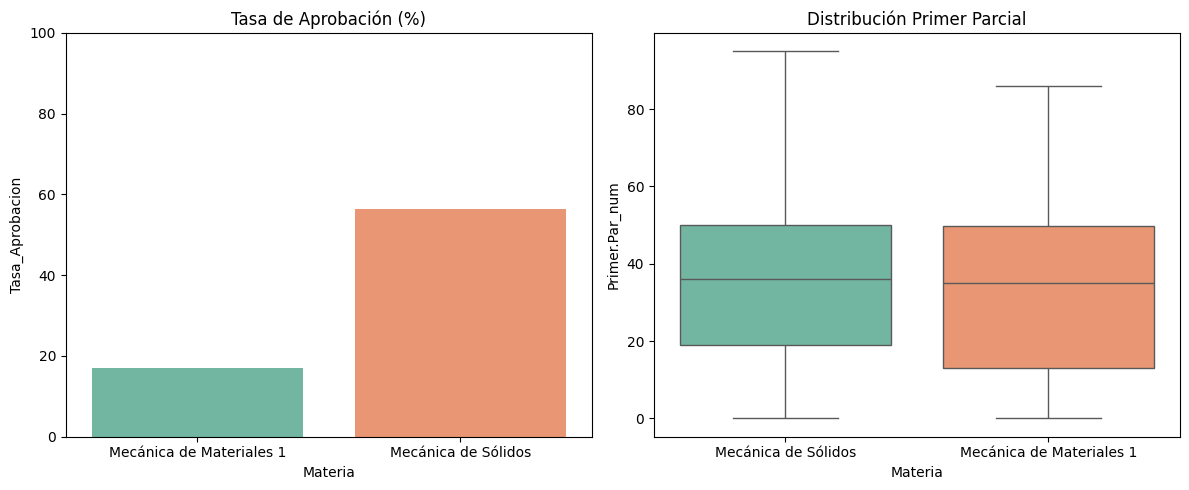

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/content/datos_concatenados.csv")

# Regex to capture both subjects flexibly
patron_mecsol = r'MECANICA DE SOLIDOS|MECÁNICA DE SÓLIDOS|MECSOL|SOLIDOS|SÓLIDOS'
patron_mat1 = r'MECANICA DE MATERIALES 1|MECÁNICA DE MATERIALES I|RESISTENCIA DE MATERIALES 1|RESISTENCIA DE MATERIALES I'

mask_mecsol = df['Asignatura'].astype(str).str.upper().str.contains(patron_mecsol, na=False, regex=True)
mask_mat1 = df['Asignatura'].astype(str).str.upper().str.contains(patron_mat1, na=False, regex=True)

df_mecsol = df[mask_mecsol].copy()
df_mat1 = df[mask_mat1].copy()

df_mecsol['Materia'] = 'Mecánica de Sólidos'
df_mat1['Materia'] = 'Mecánica de Materiales 1'

df_comp = pd.concat([df_mecsol, df_mat1], ignore_index=True)

print("="*60)
print("📊 RESUMEN COMPARATIVO")
print("="*60)
print(f"• Registros Mecsol: {len(df_mecsol):,}")
print(f"• Registros Mec. Materiales 1: {len(df_mat1):,}")

# Comparison Table
resumen = df_comp.groupby('Materia').agg(
    Registros=('Aprobado', 'count'),
    Tasa_Aprobacion=('Aprobado', lambda x: (x == 'S').mean() * 100),
    Promedio_Firma=('Firma', lambda x: pd.to_numeric(x, errors='coerce').mean()),
    Promedio_Parcial_1=('Primer.Par', lambda x: pd.to_numeric(x, errors='coerce').mean())
).reset_index()

print("\n", resumen)

# Comparative Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Approval Rate Comparison
sns.barplot(data=resumen, x='Materia', y='Tasa_Aprobacion', ax=axes[0], palette='Set2')
axes[0].set_title('Tasa de Aprobación (%)')
axes[0].set_ylim(0, 100)

# 2. Score Comparison
if 'Primer.Par' in df_comp.columns:
    df_comp['Primer.Par_num'] = pd.to_numeric(df_comp['Primer.Par'], errors='coerce')
    sns.boxplot(data=df_comp, x='Materia', y='Primer.Par_num', ax=axes[1], palette='Set2')
    axes[1].set_title('Distribución Primer Parcial')

plt.tight_layout()
plt.show()

**PROBABILIDAD DE PASAR MM1 ACORDE A TU DESEMPEÑO EN ESTATICA**

📊 ALUMNOS CON NOTA VALIDA EN ESTÁTICA: 224 / 224

📋 CANTIDAD DE ALUMNOS POR CATEGORÍA:


Estado_MM1,No,Sí
Rendimiento_Estatica,,
Bajo (1-2),130,16
Medio (3),56,12
Alto (4-5),8,2



📈 PROPORCIÓN / PROBABILIDAD DE APROBAR MM1 (%):


Estado_MM1,No,Sí
Rendimiento_Estatica,,
Bajo (1-2),89.04,10.96
Medio (3),82.35,17.65
Alto (4-5),80.00,20.00


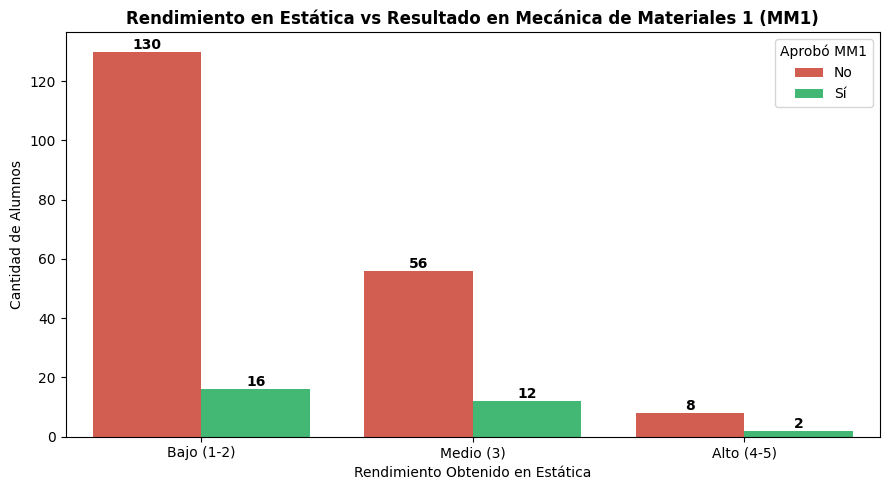

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# =============================================================================
# 1. FUNCIÓN PARA EXTRAER LA NOTA DEFINITIVA DEL FORMATO FIUNA ('1F-2', '2F-4', etc.)
# =============================================================================
def extraer_nota_fiuna(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()

    # Buscar el último número precedido de '-' (ej. '1F-4' -> 4, '1F-1,2F-3' -> 3)
    matches = re.findall(r'-\s*(\d+)', s)
    if matches:
        return float(matches[-1]) # Tomamos la última oportunidad rendida

    # Si viene solo el número directo (ej. '4' o '3.0')
    num_match = re.search(r'\b([1-5])\b', s)
    if num_match:
        return float(num_match.group(1))

    return np.nan

# =============================================================================
# 2. PROCESAMIENTO Y LIMPIEZA
# =============================================================================
df_estatica = df[df['Asignatura'].astype(str).str.upper() == 'ESTATICA'].copy()
df_mm1 = df[df['Asignatura'].astype(str).str.upper() == 'MECANICA DE MATERIALES 1'].copy()

id_col = 'ALUMNO_ID'
df_estatica[id_col] = df_estatica[id_col].astype(str).str.strip()
df_mm1[id_col] = df_mm1[id_col].astype(str).str.strip()

# Tomar el último registro por alumno
df_est_clean = df_estatica.sort_values('Anho' if 'Anho' in df.columns else df.columns[0]).groupby(id_col).last().reset_index()
df_mm1_clean = df_mm1.sort_values('Anho' if 'Anho' in df.columns else df.columns[0]).groupby(id_col).last().reset_index()

df_merged = pd.merge(df_est_clean, df_mm1_clean, on=id_col, suffixes=('_Estatica', '_MM1'))

# Extraer nota real en números
df_merged['Nota_Estatica_Num'] = df_merged['Nota.Final_Estatica'].apply(extraer_nota_fiuna)

# Limpiar Aprobado en MM1
df_merged['Estado_MM1'] = df_merged['Aprobado_MM1'].astype(str).str.strip().str.upper().map({'S': 'Sí', 'N': 'No'})

# Filtrar solo quienes tengan nota válida en Estática
df_analisis = df_merged.dropna(subset=['Nota_Estatica_Num', 'Estado_MM1']).copy()

# Categorizar Rendimiento
df_analisis['Rendimiento_Estatica'] = pd.cut(
    df_analisis['Nota_Estatica_Num'],
    bins=[0.9, 2.9, 3.9, 5.1],
    labels=['Bajo (1-2)', 'Medio (3)', 'Alto (4-5)']
)

# =============================================================================
# 3. RESULTADOS Y VISUALIZACIÓN
# =============================================================================
print("="*70)
print(f"📊 ALUMNOS CON NOTA VALIDA EN ESTÁTICA: {len(df_analisis)} / {len(df_merged)}")
print("="*70)

print("\n📋 CANTIDAD DE ALUMNOS POR CATEGORÍA:")
conteo = pd.crosstab(df_analisis['Rendimiento_Estatica'], df_analisis['Estado_MM1'])
display(conteo)

print("\n📈 PROPORCIÓN / PROBABILIDAD DE APROBAR MM1 (%):")
prob = pd.crosstab(df_analisis['Rendimiento_Estatica'], df_analisis['Estado_MM1'], normalize='index') * 100
display(prob.round(2))

# Gráfico
plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=df_analisis,
    x='Rendimiento_Estatica',
    hue='Estado_MM1',
    palette={'Sí': '#2ecc71', 'No': '#e74c3c'}
)

plt.title('Rendimiento en Estática vs Resultado en Mecánica de Materiales 1 (MM1)', fontsize=12, fontweight='bold')
plt.xlabel('Rendimiento Obtenido en Estática')
plt.ylabel('Cantidad de Alumnos')
plt.legend(title='Aprobó MM1')

# Añadir etiquetas
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5),
                    textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**PROBABILIDAD DE PASAR R1 HABIENDO RENDIDO MAL EL 1P**

✅ Registros totales cargados: 64,295

🔍 INSPECCIÓN DE ASIGNATURAS ENCONTRADAS:
['ROBOTICA 1', 'ROBOTICA 2']
📊 Total de registros en Robótica: 252
✅ Registros válidos para análisis: 252
📌 Puntaje/Nota máxima detectada en Primer Parcial: 100

📊 PROBABILIDAD DE APROBAR ROBÓTICA 1 SEGÚN EL 1ER PARCIAL


Aprobado_Clean,No,Sí
Rendimiento_Parcial1,,
Mal / Bajo (<40 pts),46.15,53.85
Medio (40-70 pts),7.89,92.11
Alto (>70 pts),0.00,100.00



📋 CANTIDAD EXACTA DE ALUMNOS POR CATEGORÍA:


Aprobado_Clean,No,Sí
Rendimiento_Parcial1,,
Mal / Bajo (<40 pts),72,84
Medio (40-70 pts),6,70
Alto (>70 pts),0,20


<Figure size 900x500 with 0 Axes>

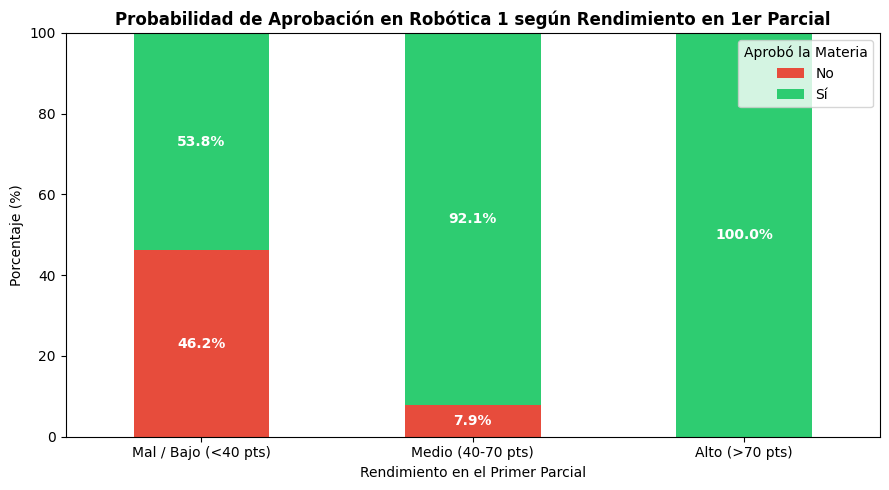

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# =============================================================================
# 1. CARGAR DATOS Y FILTRAR ROBÓTICA 1
# =============================================================================
try:
    df = pd.read_csv("/content/datos_concatenados.csv", low_memory=False)
    print(f"✅ Registros totales cargados: {len(df):,}")
except Exception as e:
    print(f"❌ Error al cargar el CSV: {e}")

# Expresión regular para capturar la materia Robótica 1
patron_robotica = r'ROBOTICA 1|ROBÓTICA 1|ROBOTICA I|ROBÓTICA I|ROBOTICA'
mask_robotica = df['Asignatura'].astype(str).str.upper().str.contains(patron_robotica, na=False, regex=True)

df_robo = df[mask_robotica].copy()

print("\n🔍 INSPECCIÓN DE ASIGNATURAS ENCONTRADAS:")
print(df_robo['Asignatura'].unique().tolist())
print(f"📊 Total de registros en Robótica: {len(df_robo):,}")

# =============================================================================
# 2. LIMPIEZA DE DATOS (PRIMER PARCIAL Y APROBACIÓN)
# =============================================================================
# Convertir el primer parcial a número
df_robo['Primer_Parcial_Num'] = pd.to_numeric(df_robo['Primer.Par'], errors='coerce')

# Mapear estado de aprobación
df_robo['Aprobado_Clean'] = df_robo['Aprobado'].astype(str).str.strip().str.upper().map({
    'S': 'Sí', '1': 'Sí', '1.0': 'Sí',
    'N': 'No', '0': 'No', '0.0': 'No'
})

# Filtrar registros con datos válidos en el Primer Parcial y Aprobado
df_analisis_robo = df_robo.dropna(subset=['Primer_Parcial_Num', 'Aprobado_Clean']).copy()

print(f"✅ Registros válidos para análisis: {len(df_analisis_robo):,}")

# Define el umbral del Parcial:
# Si el parcial se evalúa sobre 100/60 pts o escala de nota 1-5, definimos los rangos.
max_parcial = df_analisis_robo['Primer_Parcial_Num'].max()
print(f"📌 Puntaje/Nota máxima detectada en Primer Parcial: {max_parcial}")

if max_parcial <= 5: # Si las parciales están en escala 1 a 5
    bins_parcial = [-0.1, 2.5, 3.5, 5.1]
    labels_parcial = ['Mal / Bajo (1-2)', 'Medio (3)', 'Alto (4-5)']
else: # Si las parciales son sobre puntajes acumulativos (ej. 0 a 30 o 0 a 100)
    umbral_bajo = max_parcial * 0.40  # Menos del 40% del puntaje total
    umbral_medio = max_parcial * 0.70 # Entre 40% y 70%
    bins_parcial = [-0.1, umbral_bajo, umbral_medio, max_parcial + 1]
    labels_parcial = [f'Mal / Bajo (<{int(umbral_bajo)} pts)', f'Medio ({int(umbral_bajo)}-{int(umbral_medio)} pts)', f'Alto (>{int(umbral_medio)} pts)']

df_analisis_robo['Rendimiento_Parcial1'] = pd.cut(
    df_analisis_robo['Primer_Parcial_Num'],
    bins=bins_parcial,
    labels=labels_parcial
)

# =============================================================================
# 3. RESULTADOS Y TABLAS DE PROBABILIDAD
# =============================================================================
print("\n" + "="*70)
print("📊 PROBABILIDAD DE APROBAR ROBÓTICA 1 SEGÚN EL 1ER PARCIAL")
print("="*70)

prob_robo = pd.crosstab(
    df_analisis_robo['Rendimiento_Parcial1'],
    df_analisis_robo['Aprobado_Clean'],
    normalize='index'
) * 100

display(prob_robo.round(2))

print("\n📋 CANTIDAD EXACTA DE ALUMNOS POR CATEGORÍA:")
conteo_robo = pd.crosstab(
    df_analisis_robo['Rendimiento_Parcial1'],
    df_analisis_robo['Aprobado_Clean']
)
display(conteo_robo)

# =============================================================================
# 4. VISUALIZACIÓN EN GRÁFICO DE BARRAS APILADAS AL 100%
# =============================================================================
plt.figure(figsize=(9, 5))
ax = prob_robo.plot(
    kind='bar',
    stacked=True,
    color=['#e74c3c', '#2ecc71'],
    figsize=(9, 5)
)

plt.title('Probabilidad de Aprobación en Robótica 1 según Rendimiento en 1er Parcial', fontsize=12, fontweight='bold')
plt.xlabel('Rendimiento en el Primer Parcial')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Aprobó la Materia', labels=['No', 'Sí'])
plt.ylim(0, 100)
plt.xticks(rotation=0)

# Añadir porcentaje sobre cada segmento del gráfico
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Mostrar etiqueta solo si el segmento es mayor a 5%
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()